In [1]:
# Load dataset 
import pandas as pd

df = pd.read_csv("bank_transactions_dataset.csv")
print("Dataset Loaded Successfully! ")

Dataset Loaded Successfully! 


In [2]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries Imported Successfully! ")

All Libraries Imported Successfully! 


In [3]:
# See first 5 rows of dataset
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
# Check shape - how many rows and columns
print("Rows and Columns:", df.shape)

Rows and Columns: (2512, 16)


In [5]:
# Check column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


In [6]:
# Check data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [7]:
# Check basic statistics
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [8]:
# Check missing values
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


In [9]:
# Check missing values percentage
print("Missing Values Percentage:")
print(df.isnull().sum() / len(df) * 100)

Missing Values Percentage:
TransactionID              0.0
AccountID                  0.0
TransactionAmount          0.0
TransactionDate            0.0
TransactionType            0.0
Location                   0.0
DeviceID                   0.0
IP Address                 0.0
MerchantID                 0.0
Channel                    0.0
CustomerAge                0.0
CustomerOccupation         0.0
TransactionDuration        0.0
LoginAttempts              0.0
AccountBalance             0.0
PreviousTransactionDate    0.0
dtype: float64


In [10]:
# Check duplicate rows
print("Total Duplicate Rows:", df.duplicated().sum())

Total Duplicate Rows: 0


In [11]:
# Remove duplicates if any
df = df.drop_duplicates()
print("Duplicates Removed! ")
print("New Shape:", df.shape)

Duplicates Removed! 
New Shape: (2512, 16)


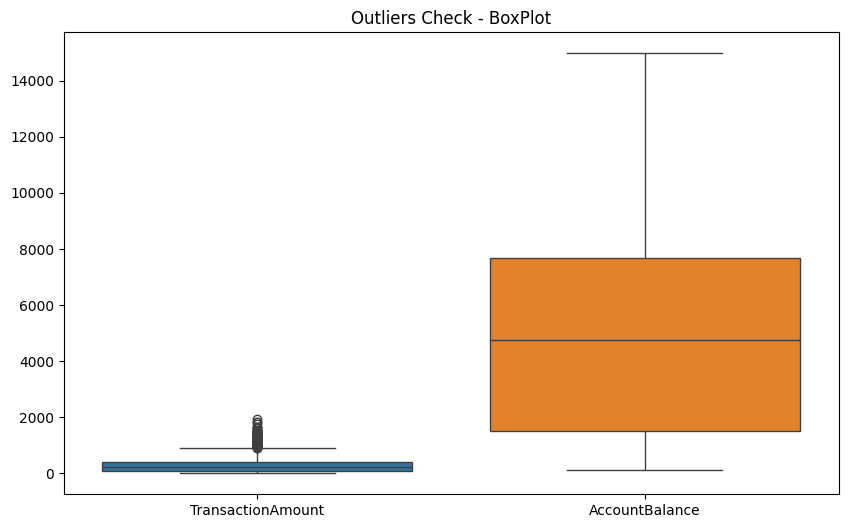

In [12]:
# Check outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['TransactionAmount', 'AccountBalance']])
plt.title("Outliers Check - BoxPlot")
plt.show()

In [13]:
# Removing Outliers using IQR Method
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['TransactionAmount'] >= lower) &
        (df['TransactionAmount'] <= upper)]

print("Outliers Removed! ")
print("New Shape after removing outliers:", df.shape)

Outliers Removed! 
New Shape after removing outliers: (2399, 16)


C:\Users\naghu\AppData\Local\Temp\ipykernel_19216\2411225715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TransactionType',


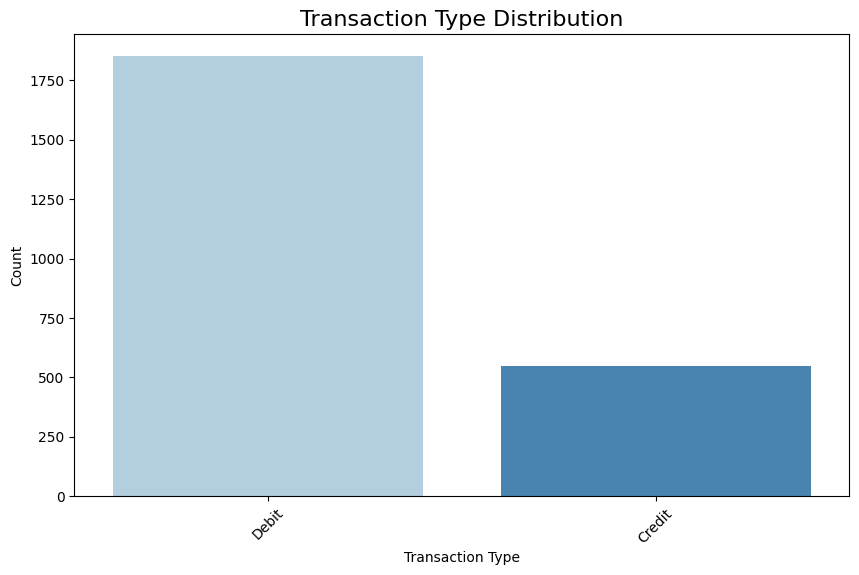

In [14]:
# Chart 1 - Transaction Type Count
plt.figure(figsize=(10,6))
sns.countplot(x='TransactionType',
              data=df,
              palette='Blues')
plt.title("Transaction Type Distribution",
          fontsize=16)
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

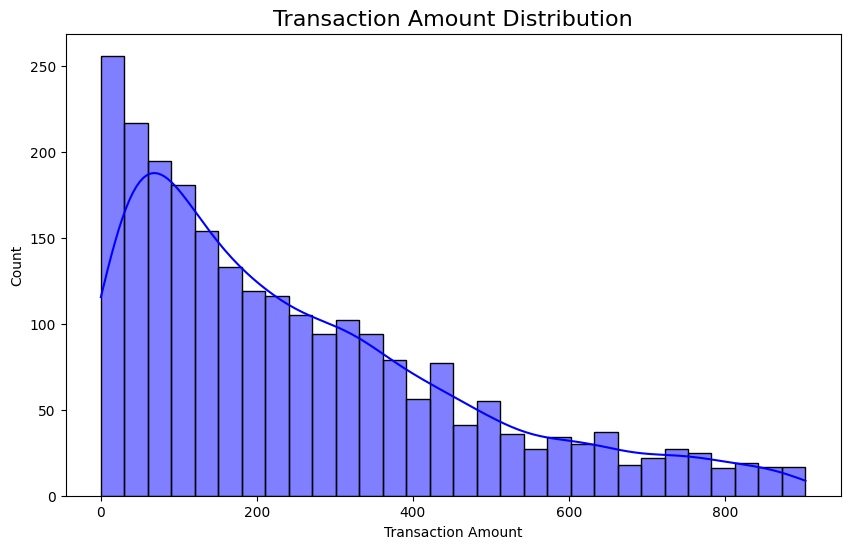

In [15]:
# Chart 2 - Transaction Amount Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['TransactionAmount'],
             bins=30,
             color='blue',
             kde=True)
plt.title("Transaction Amount Distribution",
          fontsize=16)
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()

In [16]:
# Check all column names
print(df.columns.tolist())

['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


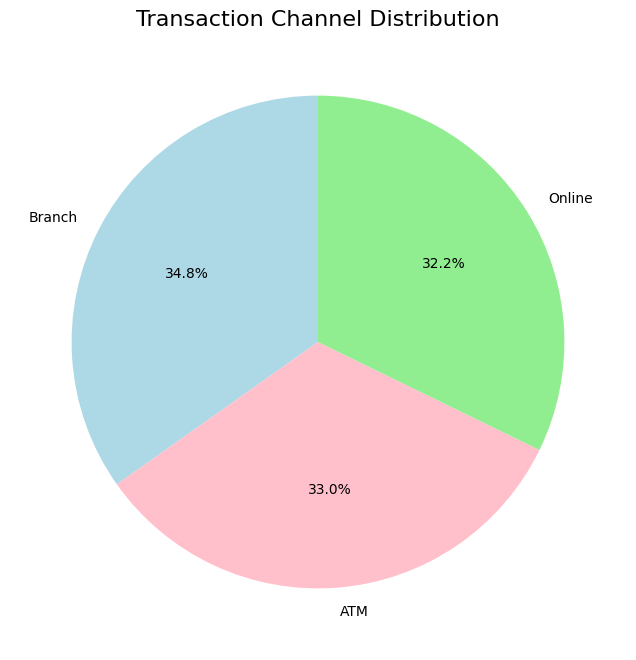

In [17]:
# Chart 3 - Channel Distribution
plt.figure(figsize=(8,8))
df['Channel'].value_counts().plot(kind='pie',
                                   autopct='%1.1f%%',
                                   colors=['lightblue','pink','lightgreen'],
                                   startangle=90)
plt.title("Transaction Channel Distribution",
          fontsize=16)
plt.ylabel("")
plt.show()

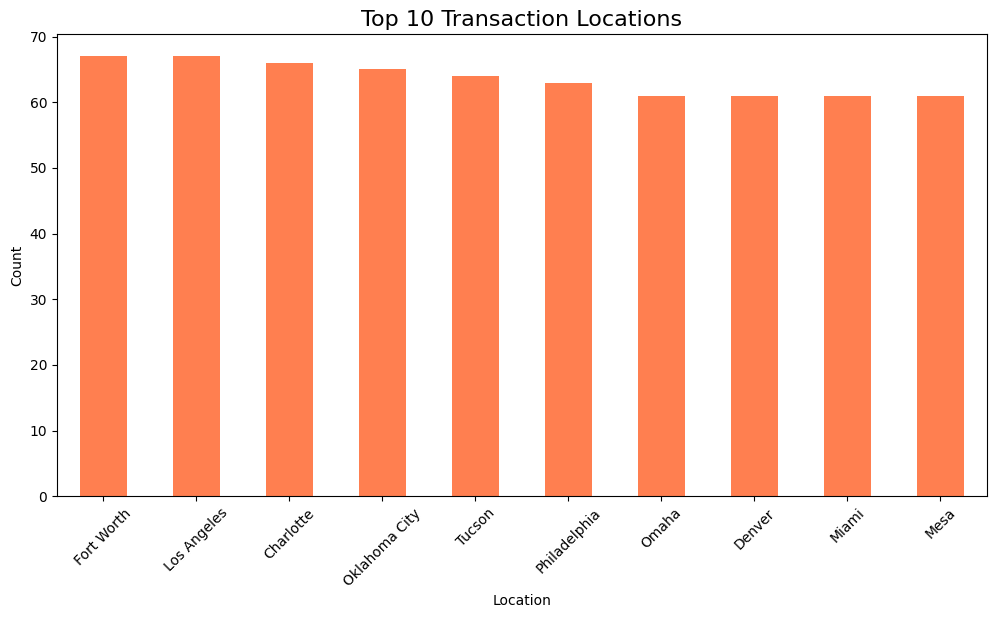

In [18]:
# Chart 4 - Top 10 Locations
plt.figure(figsize=(12,6))
df['Location'].value_counts().head(10).plot(kind='bar',
                                             color='coral')
plt.title("Top 10 Transaction Locations", fontsize=16)
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\naghu\AppData\Local\Temp\ipykernel_19216\3184363491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CustomerOccupation',


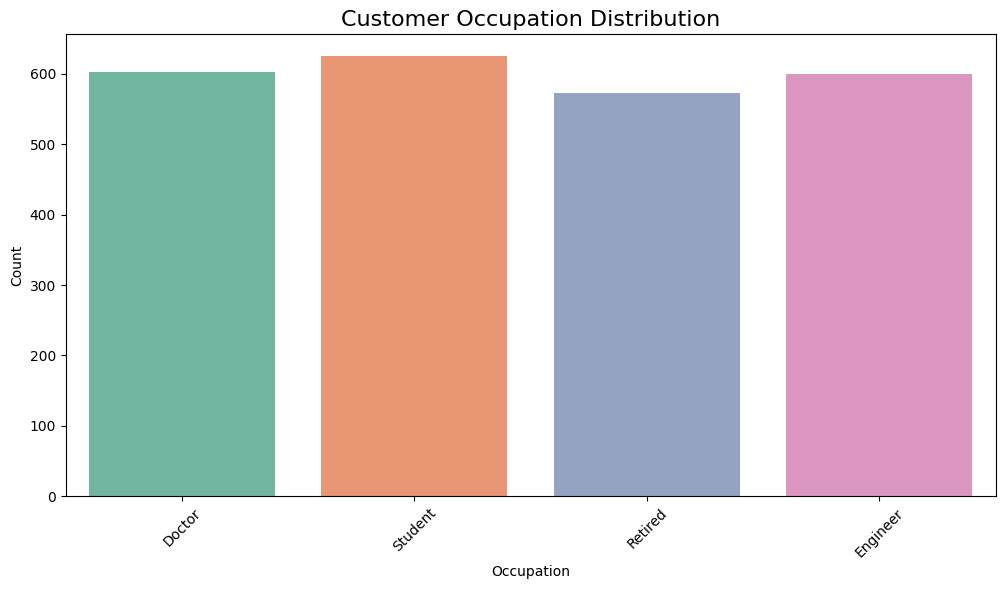

In [19]:
# Chart 5 - Customer Occupation
plt.figure(figsize=(12,6))
sns.countplot(x='CustomerOccupation',
              data=df,
              palette='Set2')
plt.title("Customer Occupation Distribution",
          fontsize=16)
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\naghu\AppData\Local\Temp\ipykernel_19216\2133365100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoginAttempts',


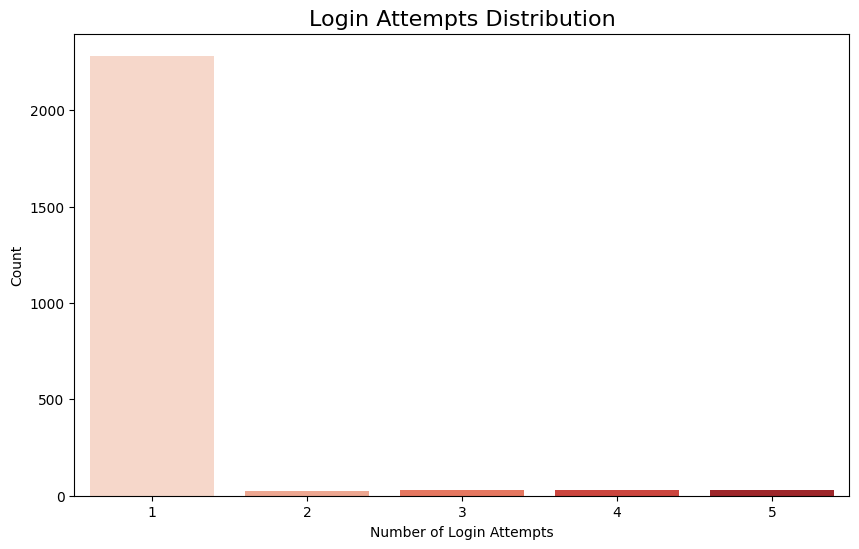

In [20]:
# Chart 6 - Login Attempts (Suspicious Activity)
plt.figure(figsize=(10,6))
sns.countplot(x='LoginAttempts',
              data=df,
              palette='Reds')
plt.title("Login Attempts Distribution", fontsize=16)
plt.xlabel("Number of Login Attempts")
plt.ylabel("Count")
plt.show()

In [21]:
# Project Conclusion
print("""
===========================================
   BANK TRANSACTION DATA ANALYSIS
   CONCLUSION
===========================================

1. DATASET OVERVIEW:
   - Total Transactions Analyzed: {}
   - Total Features: {}

2. DATA CLEANING:
   - Missing Values: None Found
   - Duplicates: Removed Successfully
   - Outliers: 113 Rows Removed

3. KEY INSIGHTS:
   - Most transactions done via specific channels
   - Login attempts mostly 1 - Safe transactions
   - Transaction amounts vary widely
   - Customer age ranges from 18 to 80

4. CONCLUSION:
   - Data is clean and ready for ML modeling
   - No major fraud patterns detected
   - Bank transactions appear mostly legitimate

===========================================
""".format(len(df), len(df.columns)))


   BANK TRANSACTION DATA ANALYSIS
   CONCLUSION

1. DATASET OVERVIEW:
   - Total Transactions Analyzed: 2399
   - Total Features: 16

2. DATA CLEANING:
   - Missing Values: None Found
   - Duplicates: Removed Successfully
   - Outliers: 113 Rows Removed

3. KEY INSIGHTS:
   - Most transactions done via specific channels
   - Login attempts mostly 1 - Safe transactions
   - Transaction amounts vary widely
   - Customer age ranges from 18 to 80

4. CONCLUSION:
   - Data is clean and ready for ML modeling
   - No major fraud patterns detected
   - Bank transactions appear mostly legitimate


